In [1]:
import os
os.getcwd()
os.chdir('/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/scripts/lasso_11_2025')


In [2]:
# Generate simulated data for testing purposes

import matplotlib.pyplot as plt

import pandas as pd
import csv
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import os
import random
from itertools import product



from stage1 import lasso_rolling_window, calculate_r_squared

from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared

## 1. Constant parameters

First we check if our procedures work when the beta paramter is constant.
In this case we just use a window size wich is equal to the total number of observations.

In [3]:
#Stage 1

#generate the matrix of regressors X with dimensions T x N, for now we set covariance matrix as identity
T = 1000  #number of time periods
N = 500   #number of potential predictors
X = np.random.normal(0, 1, (T, N)) * 0.01

#initialize the true beta coefficients
true_beta = np.zeros(N)
#we set only 10 non-zero coefficients
non_zero_indices = np.random.choice(N, 10, replace=False)
true_beta[non_zero_indices] = np.random.normal(0, 1, 10)

#now we generate the expected values of returns
expected_returns = X @ true_beta 

In [4]:
#Generate the actual returns by using the ALM
kappa = 0.5
actual_returns = np.log(1 - kappa * np.exp(expected_returns[:-1])) - np.log(1 - kappa * np.exp(expected_returns[1:])) + np.random.normal(0, 0.001, T - 1)
#add a NaN at the end  to align dimensions
actual_returns = np.append(actual_returns, 0.0)

In [5]:
# Test with the actual code we use

#make up daily dates
dates = pd.date_range(start='2000-01-01', periods=T, freq='D')
X = pd.DataFrame(X, index=dates)
y = pd.Series(index=dates, dtype=float)
y.iloc[:] = actual_returns


random.seed(42)


# ensure that all indices align
common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [6]:
window_size = 400
n_lags = 0
lambda_val = 0.001

In [7]:
try:
    
    # Stage 1: Rolling LASSO + OLS
    stage1_results = lasso_rolling_window(
        X=X, y=y, 
        window_size=window_size, 
        n_lags=n_lags,
        lambda_mode="fixed", 
        fixed_lambda=lambda_val, 
        verbose=False # Keep false to avoid spamming console in parallel
    )
   
    
    # Extract predictions and align data
    preds = np.array(stage1_results["predictions"]) #contains predictions up to r^e_{t+1} while y contains up to r_{t} so we need to align
    
    #shift preds to match y
    preds = preds[:-1] # remove last prediction to align with y
    y_valid = y[-len(preds):] if isinstance(y, (pd.Series, pd.DataFrame)) else y[-len(preds):]
    y_vals = y_valid.values if isinstance(y_valid, (pd.Series, pd.DataFrame)) else y_valid
    
    #defining de-meaned y for comparing with stage 1 errors
    y_demeaned = y_vals - np.nanmean(y_vals)
    
    # Stage 1 Metrics
    r2_oos_stage1 = calculate_r_squared(y_demeaned, preds)
    r2_insample_stage1 = np.nanmean(stage1_results['insample_r_squareds'])
    # Stage 2 Estimation
    stage2_input = pd.DataFrame({"vwretd": y_vals, "predictions": preds})
    stage2_results = compute_stage2_r_squared(stage2_input, min_train_size=100)
    
    # --- Build Summary Dictionary ---
    summary = {
        'window_size': window_size,
        'n_lags': n_lags,
        'lambda': lambda_val,
        'r2_insample_stage1': r2_insample_stage1,
        'r2_oos_stage1': r2_oos_stage1,
        'r2_insample_stage2': stage2_results['r2_insample'],
        'r2_oos_stage2': stage2_results['r2_oos'],
        'kappa': stage2_results['kappa'],
        'kappa_tstat': stage2_results['kappa_tstat'],
        'intercept': stage2_results['intercept'],
        'intercept_tstat': stage2_results['intercept_tstat'],
        'n_observations': len(y_vals),
        'n_windows': len(stage1_results['predictions']),
        'n_oos_predictions_stage2': stage2_results.get('n_oos_predictions', np.nan)
    }
    
    # --- Build Detailed Coefficients DataFrame ---
    # We construct a dataframe where each row is a time window
    n_wins = len(stage1_results['lambdas'])
    dates = stage1_results.get('window_end_dates', np.arange(n_wins))
    features = stage1_results['feature_names']
    # We will collect rows as dicts for speed then dataframe them
    detail_rows = []
    
    # Retrieve coefficient arrays (Shape: n_windows x n_features) only if 'r2_insample_stage2' > 0
    if summary['r2_insample_stage2'] > 0:
        lasso_coefs_arr = stage1_results['coefficients']
        # ols_coefs_arr = stage1_results['ols_coefficients']
    
        for i in range(n_wins):
            row = {
                'date': dates[i] if i < len(dates) else None,
                'window_size': window_size,
                'n_lags': n_lags,
                'lambda': lambda_val,
                'window_index': i,
                # Intercepts / R2
                'lasso_intercept': stage1_results['intercepts'][i],
                # 'ols_intercept': stage1_results['ols_intercepts'][i],
                'lasso_r2_in': stage1_results['insample_r_squareds'][i],
                'prediction_error': stage1_results['prediction_errors'][i],
                # 'ols_r2_in': stage1_results['ols_insample_r2'][i],
                'num_nonzero_coefficients': stage1_results['num_nonzero_coefficients'][i]
            }
            # Add feature coefficients
            # Naming convention: Lasso_FeatureName, OLS_FeatureName
            for f_idx, f_name in enumerate(features):
                row[f"Lasso_{f_name}"] = lasso_coefs_arr[i, f_idx]
                # row[f"OLS_{f_name}"] = ols_coefs_arr[i, f_idx]
            detail_rows.append(row)
    else:
        detail_rows.append({
            'date': None,
            'window_size': window_size,
            'n_lags': n_lags,
            'lambda': lambda_val,
            'window_index': None,
            'lasso_intercept': np.nan,
            # 'ols_intercept': np.nan,
            'lasso_r2_in': np.nan,
            'prediction_error': np.nan,
            # 'ols_r2_in': np.nan,
            'num_nonzero_coefficients': np.nan
        })
        
    details_df = pd.DataFrame(detail_rows)
    
    
    
except Exception as e:
    # Return error dict for summary, empty df for details
    error_summary = {
        'window_size': window_size,
        'n_lags': n_lags,
        'lambda': lambda_val,
        'error': str(e),
        'kappa': np.nan, 
        'r2_oos_stage2': np.nan
    }
    



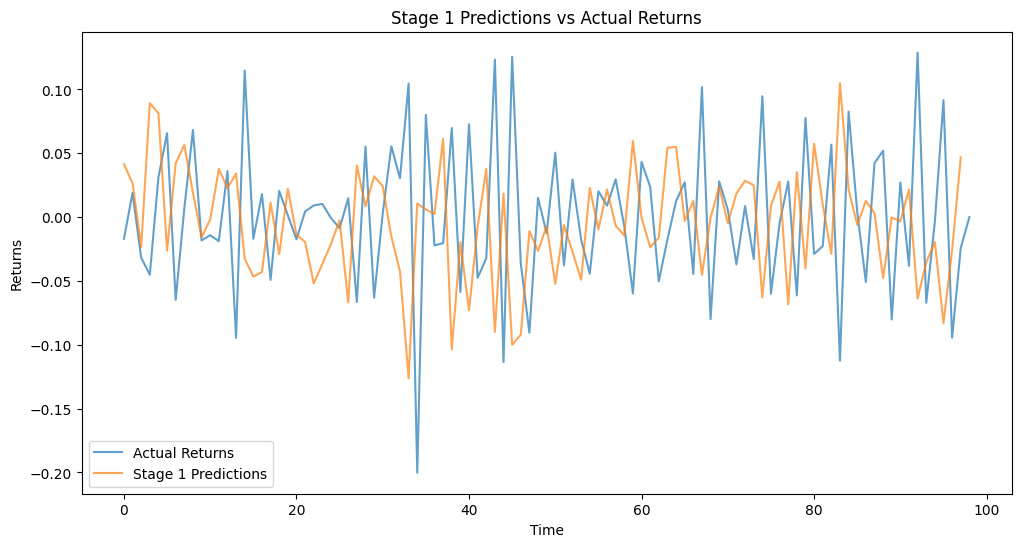

In [9]:
#visualize stage1 predictions vs actual y
zoom_index = slice(500, 700)  # Adjust indices for zooming in
y_vals_zoom = y_demeaned[zoom_index]
preds_zoom = preds[zoom_index]
plt.figure(figsize=(12,6))
plt.plot(y_vals_zoom, label='Actual Returns', alpha=0.7)
plt.plot(preds_zoom, label='Stage 1 Predictions', alpha=0.7)
plt.legend()
plt.title('Stage 1 Predictions vs Actual Returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.show()

<BarContainer object of 500 artists>

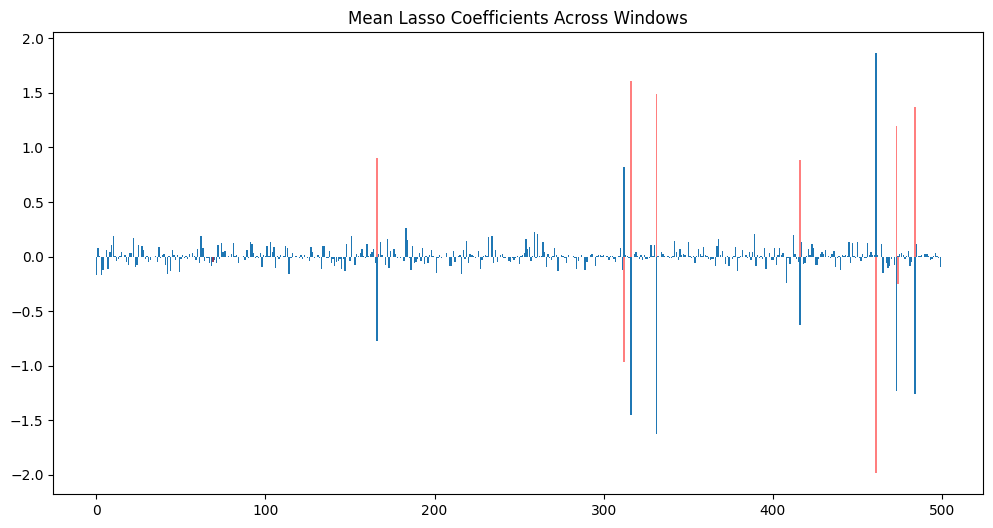

In [10]:
#visualzie stage 1 coefficients
lasso_coefs_arr = stage1_results['coefficients']
mean_coefs = np.nanmean(lasso_coefs_arr, axis=0)
plt.figure(figsize=(12,6))
plt.bar(range(len(mean_coefs)), mean_coefs)
plt.title('Mean Lasso Coefficients Across Windows')    
#add actual coefficients
plt.bar(range(len(true_beta)), true_beta, alpha=0.5, color='red') 